# <center> **ML-3. Обучение с учителем: классификация**

>**Задача классификации (classification)** — задача, в которой мы пытаемся предсказать класс объекта на основе признаков в наборе данных. То есть задача сводится к предсказанию целевого признака, который является **категориальным**.

Когда классов, которые мы хотим предсказать, только два, классификация называется **бинарной**. 

Когда классов, которые мы хотим предсказать, более двух, классификация называется **мультиклассовой (многоклассовой)**.

Что вообще означает «решить задачу классификации»? Это значит построить разделяющую поверхность в пространстве признаков, которая делит пространство на части, каждая из которых соответствует определённому классу. 

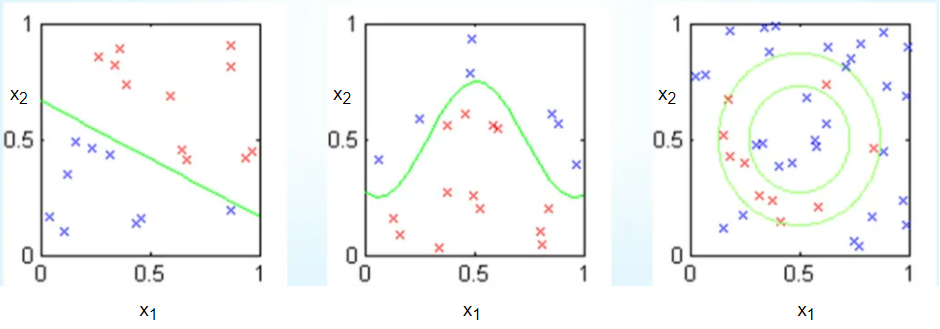

>Модели, которые решают задачу классификации, называются **классификаторами (classifier)**.

Если взять в качестве разделяющей поверхности некоторую плоскость (ровная поверхность на первом рисунке), то мы получаем модель **логистической регрессии**, которая тесно связана с рассмотренной нами ранее линейной регрессией.

Давайте для начала вспомним, как выглядит уравнение модели линейной регрессии в общем случае:
$$\hat{y}=w_0+w_1x_1+w_2x_2+\dots + w_mx_m=w_0+\sum _{j=1} ^{m} w_jx_j $$

В общем случае это уравнение гиперплоскости, которая стремится приблизить зависимость целевой переменной от  факторов.
* Когда фактор всего один, уравнение задаёт прямую:
$$\hat{y}=w_0+w_1x$$
* Когда факторов два, уравнение задаёт плоскость:
$$\hat{y}=w_0+w_1x_1+w_2x_2$$

>Переведём задачу классификации в задачу регрессии. Вместо предсказания класса будем предсказывать вероятность принадлежности к этому классу. 

Модель должна выдавать некоторую вероятность P, которая будет определять, принадлежит ли данный объект к классу 1: например, вероятность того, что письмо является спамом. При этом вероятность того, что письмо является обычным письмом (класс 0), определяется как Q = 1-P.  

Когда модель будет обучена на предсказание вероятности, мы зададим некоторый порог вероятности. Если предсказанная вероятность будет выше этого порога, мы определим объект к классу 1, а если ниже — к классу 0.

Например, стандартный порог равен 0.5. То есть если вероятность $P>0.5$, мы будем считать письмо спамом, а если $P \leq 0.5$ — обычным информативным письмом.

В итоге мы добьёмся того, что будем предсказывать не дискретный категориальный, а непрерывный числовой признак, который лежит в диапазоне [0, 1]. А это уже знакомая нам задача регрессии.

>Однако остался главный вопрос: как научить модель предсказывать вероятности, ведь они должны лежать строго в диапазоне от 0 до 1, а предсказания линейной регрессии лежат в диапазоне от $-\infty$ до $\infty$? 

**Тут-то мы и приходим к модели логистической регрессии — регрессии вероятностей.**

---

### <center> ОБЩЕЕ ПРЕДСТАВЛЕНИЕ О ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ

>**Логистическая регрессия (Logistic Regression)** — одна из простейших моделей для решения задачи классификации. Несмотря на простоту, модель входит в топ часто используемых алгоритмов классификации в Data Science.

В основе логистической регрессии лежит логистическая функция (logistic function) $\sigma(z)$ — отсюда и название модели. Однако более распространённое название этой функции — **сигмόида (sigmoid)**. Записывается она следующим образом:
$$\sigma(z)=\frac{1}{1+e^{-z}}$$

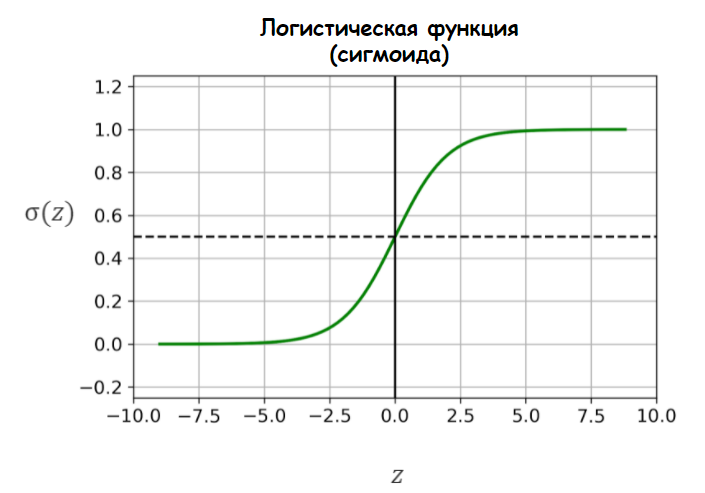

>У сигмоиды есть два очень важных для нас свойства:
* Значения сигмоиды $\sigma(z)$ лежат в диапазоне от 0 до 1 при любых значения аргумента z: какой бы z вы ни подставили, число меньше 0 или больше 1 вы не получите.
* Сигмоида выдаёт значения $\sigma(z)>0.5$ при её аргументе z>0, $\sigma(z)<0.5$ — при z<0 и $\sigma(z)=0.5$ — при z=0.

Это ведь и есть свойства вероятности! Выходом сигмоиды является число от 0 до 1, которое можно интерпретировать как вероятность принадлежности к классу 1. Её мы и пытаемся предсказать.

**Основная идея** модели логистической регрессии: возьмём модель линейной регрессии (обозначим её выход за z)
$$z=w_0+\sum _{j=1} ^m w_jx_j$$

и подставим выход модели z в функцию сигмоиды, чтобы получить искомые оценки вероятности (в математике принято писать оценочные величины с «шапкой» наверху, а истинные значения — без «шапки», это чистая формальность):
$$\hat{P}=\sigma(z)=\frac{1}{1+e^{-z}}=\frac{1}{1+e^{-w_0-\sum _{j=1} ^m w_jx_j}}= \frac{1}{1+e^{-\bar{w}\bar{x}}}$$

>**Примечание**. Далее в модуле мы будем называть оценки вероятности $\hat{P}$ просто вероятностью, но только для краткости. Это не значит, что эти оценки являются истинными вероятностями принадлежности к каждому из классов (их нельзя сосчитать, так как для этого нужна выборка бесконечного объёма). Если вы употребляете термин «вероятности» на собеседованиях, обязательно предварительно укажите, что вы подразумеваете оценку вероятности.

Обучать будем всё в совокупности, пытаясь получить наилучшую оценку вероятности $\hat{P}$. Если вероятность $\hat{P}>0.5$, относим объект к классу 1, а если $\hat{P} \leq 0.5$, относим объект к классу 0. 

Математически это записывается следующей формулой:
$$\hat{y}=I[\hat{P}]=
    \begin{cases}
        1, \hat{P}>0.5  \\
        0, \hat{P} \leq 0.5 
    \end{cases} $$

>**Примечание**. В данном выражении $I[\hat{P}]$ называется **индикаторной функцией**. Она возвращает 1, если её значение больше какого-то порога, и 0 — в противном случае. Математики часто записывают просто квадратные скобки, опуская символ I: $[\hat{P}]$.

Если мы обучим модель, то есть подберём  коэффициенты $w_0,w_1,\dots , w_m$ (как их найти, обсудим чуть позже) таким образом, что для объектов класса 1 модель линейной регрессии начнёт выдавать положительное число, а для класса 0 — выдавать отрицательное число, то тогда, подставив предсказание линейной регрессии z в сигмоиду, мы сможем получать вероятности принадлежности к каждому из классов в диапазоне от 0 до 1.

Далее по порогу вероятности мы сможем определять, к какому классу принадлежит объект.

Это и есть наша цель. Мы свели задачу классификации к задаче регрессии для предсказания вероятностей. 

Для бинарной классификации описанное выше будет выглядеть следующим образом:

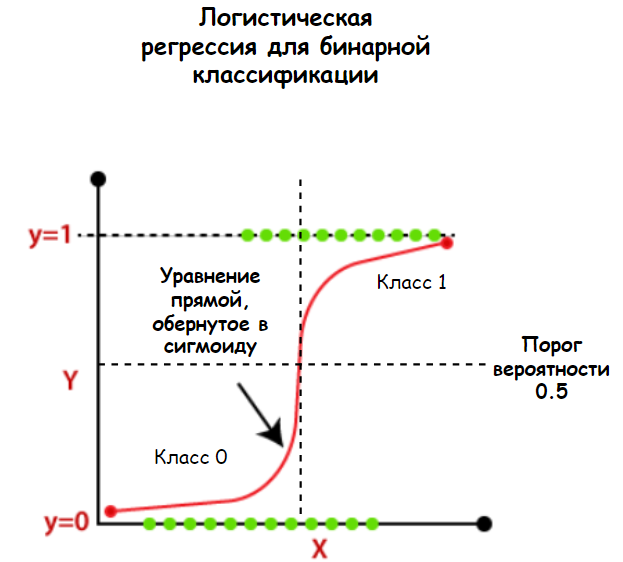

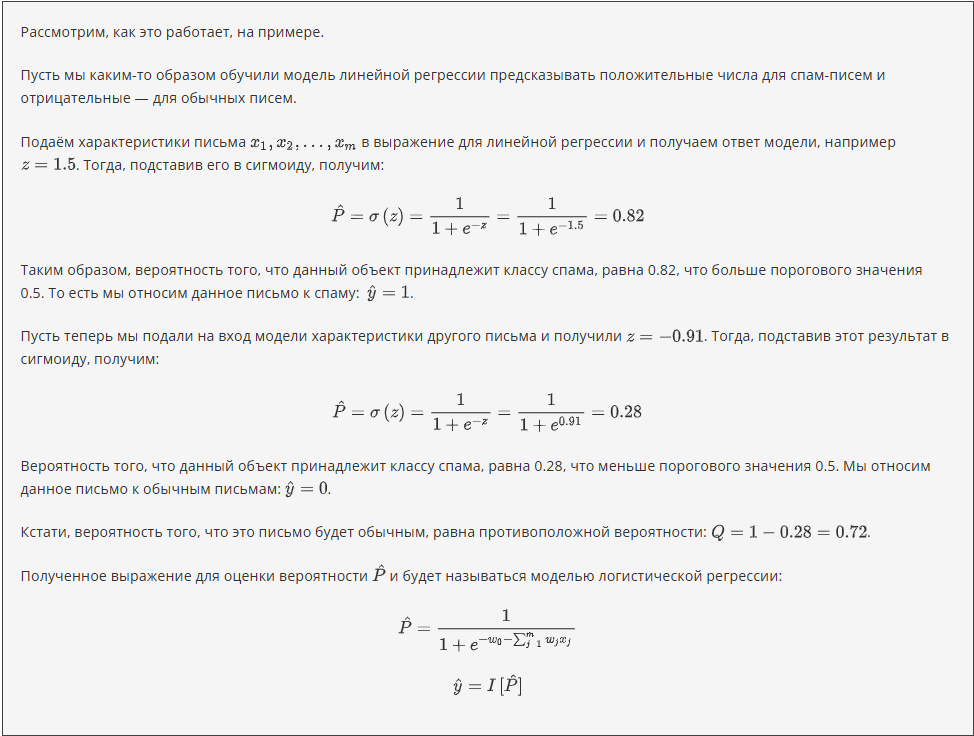

Математически подстановка в уравнение плоскости точки, которая не принадлежит ей (находится ниже или выше), означает вычисление расстояния от этой точки до плоскости.
* Если точка находится ниже плоскости, расстояние будет отрицательным ($z<0$).
* Если точка находится выше плоскости, расстояние будет положительным ($z>0$).
* Если точка находится на самой плоскости, $z=0$.

Мы знаем, что подстановка отрицательных чисел в сигмоиду приведёт к вероятности $\hat{P}<0.5$, а постановка положительных — к вероятности $\hat{P}>0.5$. 

>Таким образом, ключевым моментом в предсказании логистической регрессии является расстояние от точки до разделяющей плоскости в пространстве факторов. Это расстояние в литературе часто называется **отступом (margin)**. 

>Чем больше расстояние от точки, находящейся выше разделяющей плоскости, до самой плоскости, тем больше оценка вероятности принадлежности к классу 1.

Можно построить тепловую карту, которая показывает, чему равны вероятности в каждой точке пространства:

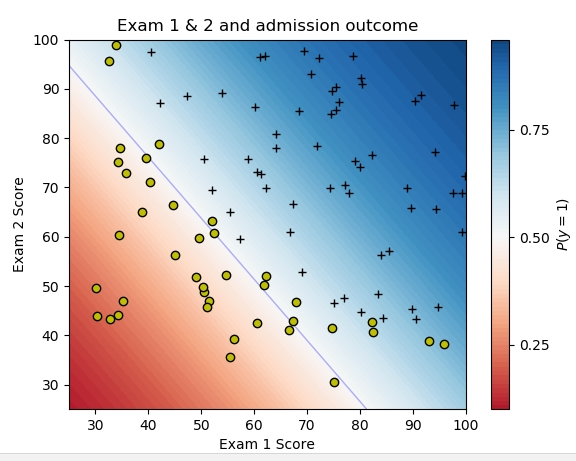

Для случая зависимости целевого признака y от трёх факторов $x_1,x_2,x_3$,  и , например от баллов за два экзамена и рейтинга университета, из которого выпустился абитуриент, выражение для z будет иметь вид:
$$z=w_0+w_1x_1+w_2x_2+w_3x_3$$
Уравнение задаёт плоскость в четырёхмерном пространстве. Но если вспомнить, что y — категориальный признак и классы можно обозначить цветом, то получится перейти в трёхмерное пространство. Разделяющая плоскость будет выглядеть следующим образом:

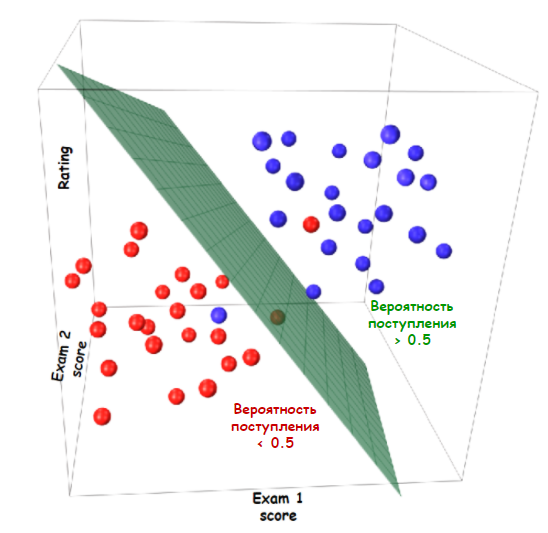

В общем случае, когда у нас есть зависимость от m факторов, линейное выражение, находящееся под сигмоидой, будет обозначать **разделяющую гиперплоскость**.

---

# <center> ПОИСК ПАРАМЕТРОВ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ

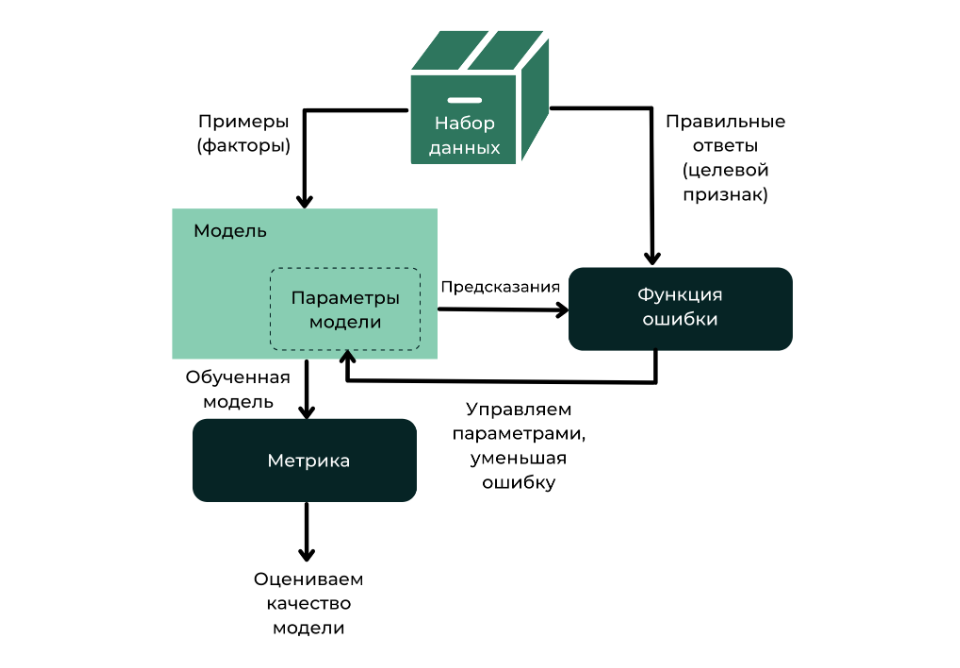

### **Метод максимального правдоподобия (Maximum Likelihood Estimation — MLE)**

>**Правдоподобие** — это оценка того, насколько вероятно получить истинное значение целевой переменной y при данных x и параметрах w. 

**Цель метода** — найти такие параметры $w=(w_0,w_1, \dots, w_m)$, в которых наблюдается максимум функции правдоподобия. Подробнее о выводе формулы вы можете прочитать [здесь](https://habr.com/ru/articles/485872/).

$$likelihood=\sum_{i}^{n}(y_i log(\hat{P_i})+(1-y_i) log(1-\hat{P_i})) \to max_w$$

Давайте разберёмся, что есть что и как работает эта функция.
* n — количество наблюдений.
* $y_i$ — это истинный класс (1 или 0) для i-ого объекта из набора данных.
* $\hat{P_i}$ — предсказанная с помощью логистической регрессии вероятность принадлежности к классу 1 для i-ого объекта из набора данных.
* $z_i$ — результат подстановки i-ого объекта из набора данных в уравнение разделяющей плоскости $z_i=\bar{w \cdot \bar{x}}$.
* log — логарифм (обычно используется натуральный логарифм по основанию e - ln).

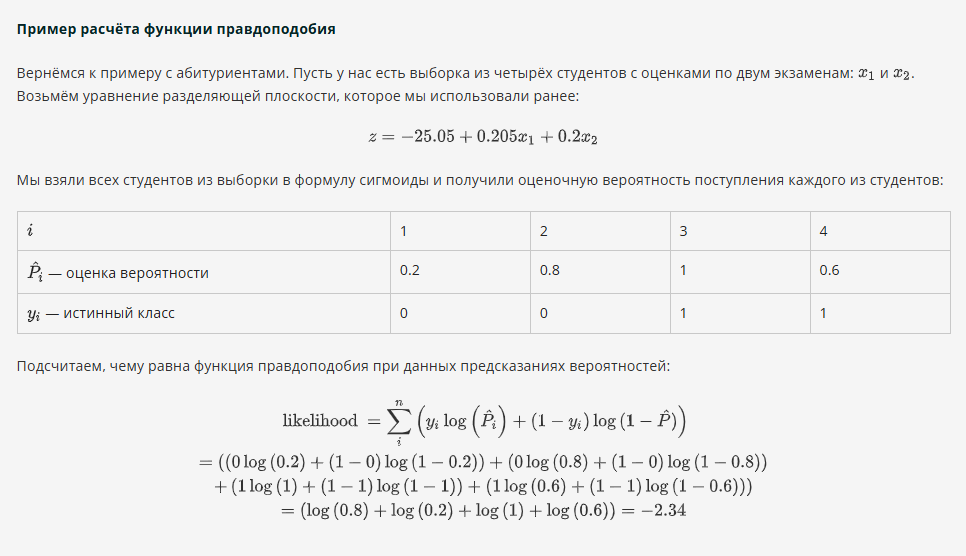

Цель — найти такие параметры, при которых наблюдается максимум этой функции.

Теперь пора снова применить магию математики, чтобы привести задачу к привычному нам формату минимизации эмпирического риска. По правилам оптимизации, если поставить перед функцией минус, то задача оптимизации меняется на противоположную: был поиск максимума — станет поиском минимума.

Таким образом мы получим функцию потерь $L(w)$, которая носит название **«функция логистических потерь»**, или **logloss**. Также часто можно встретить название **кросс-энтропия**, или **cross-entropy loss**:

$$L(w)=logloss= - \sum_{i}^{n}(y_i log(\hat{P_i})+(1-y_i) log(1-\hat{P_i})) \to min_w$$
$$\hat{P_i} = \frac{1}{1+e^{-w_0-\sum_{j=1} ^{m} w_jx_j}}$$

Вот эту функцию мы и будем минимизировать в рамках поиска параметров логистической регрессии. Мы должны найти такие параметры разделяющей плоскости  w, при которых наблюдается минимум logloss.

>К сожалению, для такой функции потерь аналитическое решение оптимизационной задачи найти не получится: при расчётах получается, что его попросту не существует.

Но мы помним, что, помимо аналитических решений, есть и численные.

Например, для поиска параметров можно использовать знакомый нам градиентный спуск. Вспомним, как выглядит итерационная формула данного метода:
$$w^{(k+1)}=w^{(k)} - \eta \bigtriangledown L(w^{(k)})$$

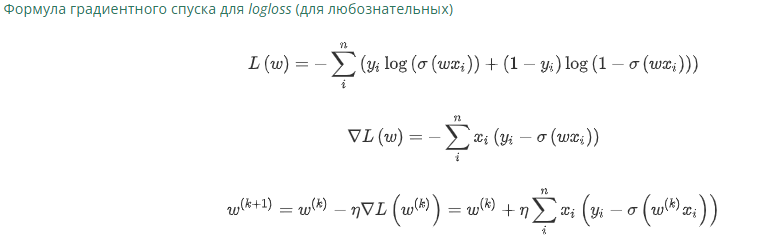

>Мы уже знаем, что для того, чтобы повысить шанс пройти мимо локальных минимумов функции потерь, используется не сам градиентный спуск, а его модификации: например, можно использовать уже знакомый нам стохастический градиентный спуск (SGD).

Во избежание переобучения модели в функцию потерь логистической регрессии традиционно добавляется **регуляризация**. В реализации логистической регрессии в sklearn она немного отличается от той, что мы видели ранее для линейной регрессии.

При L1-регуляризации мы добавляем в функцию потерь $L(w)$ штраф из суммы модулей параметров, а саму функцию logloss умножаем на коэффициент C:
$$L(w)= C \cdot logloss + \sum_{j=1} ^{m} |w_j| \to min_w$$
А при L2-регуляризации — штраф из суммы квадратов параметров:
$$L(w) = C \cdot logloss + \sum_{j=1} ^{m} (w_j)^2 \to min_w $$


Значение коэффициента  C — коэффициент, обратный коэффициенту регуляризации. Чем больше C, тем меньше «сила» регуляризации.

---

# <center> **ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ В SKLEARN**

In [5]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации


import warnings # для игнорирования предупреждений
#Игнорируем предупреждения
warnings.filterwarnings('ignore')


# Устанавливаем стиль визуализаций в matplotlib
%matplotlib inline
plt.style.use('seaborn-v0_8')

In [7]:
diabetes_data = pd.read_csv('data_ml3/diabetes_cleaned.csv')
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,98.0,58.0,33.0,34.0,0.430,43,0
1,2,112.0,75.0,32.0,35.7,0.148,21,0
2,2,108.0,64.0,29.0,30.8,0.158,21,0
3,8,107.0,80.0,29.0,24.6,0.856,34,0
4,7,136.0,90.0,29.0,29.9,0.210,50,0


Напомним, какие признаки у нас есть:
* Pregnancies — количество беременностей;
* Glucose — концентрация глюкозы в плазме через два часа при пероральном тесте на толерантность к глюкозе;
* BloodPressure — диастолическое артериальное давление (мм рт. ст.);
* SkinThickness — толщина кожной складки трицепса (мм);
* BMI — индекс массы тела (вес в кг/рост в м)^2;
* DiabetesPedigreeFunction — функция родословной диабета (чем она выше, тем выше шанс наследственной заболеваемости);
* Age — возраст;
* Outcome — наличие диабета (0 — нет, 1 — да), **целевой признак**.

Размер таблицы:

In [8]:
print(diabetes_data.shape)

(757, 8)


Давайте посмотрим на матрицу корреляций и выберем наиболее коррелированные с целевым признаком факторы:

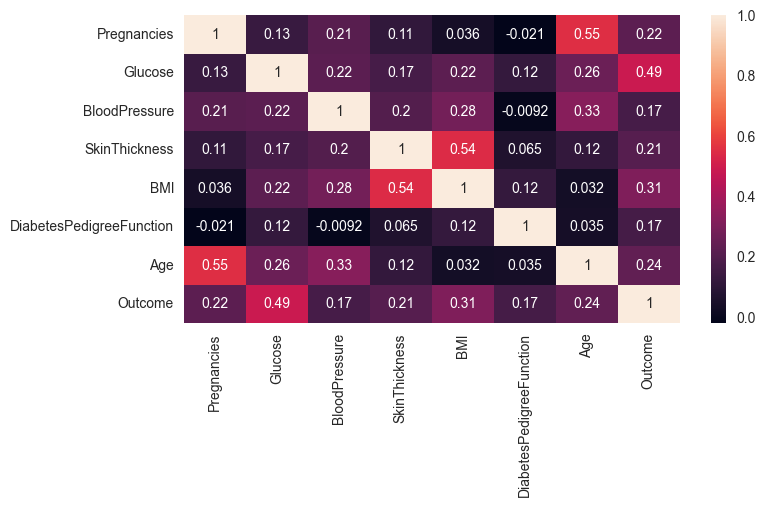

In [9]:
fig, ax = plt.subplots(figsize = (8, 4))
sns.heatmap(diabetes_data.corr(), annot=True);

Из строки Outcome видно, что наибольшей корреляцией с целевым признаком обладают факторы Glucose (уровень глюкозы) и BMI (индекс массы тела).

Построим диаграмму рассеяния, по оси абсцисс отложим фактор Glucose, а по оси ординат — BMI. Сделаем цветовую группировку по признаку наличия диабета:

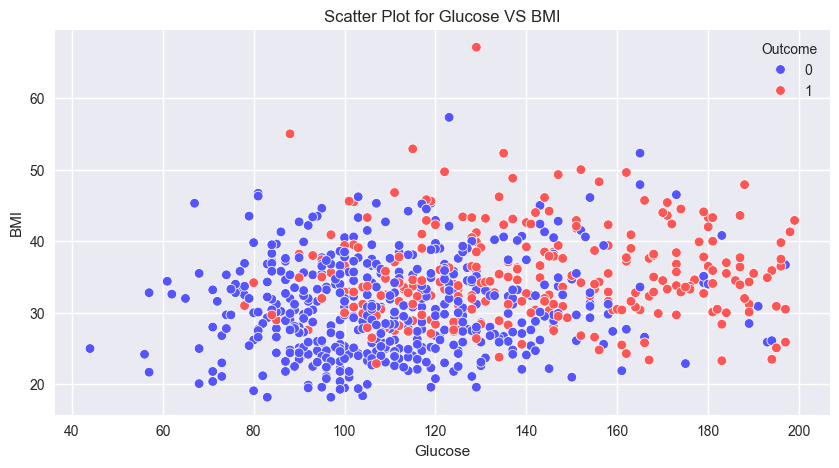

In [10]:
fig, ax = plt.subplots(figsize = (10, 5)) #фигура + координатная плоскость
#Строим диаграмму рассеяния
sns.scatterplot(
    data=diabetes_data, #датасет
    x='Glucose', #ось абсцисс
    y='BMI', #ось ординат
    hue='Outcome', #группировка
    palette='seismic', #палитра
    ax=ax, #координатная плоскость
);

#Задаём название графику
ax.set_title('Scatter Plot for Glucose VS BMI');

Видно, что классы довольно сильно перемешаны, но красные точки, соответствующие пациентам с диабетом, преимущественно сгруппированы в правой части системы координат.

Давайте попробуем построить разделяющую плоскость с помощью логистической регрессии.

Для начала разделим выборку на матрицу наблюдений X, состоящую из двух признаков, и столбец с правильным ответами y:

In [11]:
#Создаём матрицу наблюдений X и столбец с ответами y
X = diabetes_data[['Glucose', 'BMI']]
y = diabetes_data['Outcome']

Логистическая регрессия — линейная модель, поэтому она находится в уже знакомом нам модуле linear_model из библиотеки sklearn.

In [12]:
from sklearn import linear_model #линейные модели

В модуле находится класс ```LogisticRegression```, который реализует поиск коэффициентов разделяющей плоскости путём минимизации функции потерь ```logloss``` различными численными методами.

**Основные параметры LogisticRegression**:
* ```random_state``` — число, на основе которого происходит генерация случайных чисел.
* ```penalty``` — метод регуляризации. Возможные значения:
    * ```'l1'``` — L1-регуляризация;
    * ```'l2'``` — L2-регуляризация (используется по умолчанию);
    * ```'elasticnet'``` — эластичная сетка (L1+L2);
    * ```'None'``` — отсутствие регуляризации.
* ```C``` — коэффициент обратный коэффициенту регуляризации, то есть равен $\frac{1}{\alpha}$. Чем больше C, тем меньше регуляризация. По умолчанию C=1, тогда α=1.
* ```solver``` — численный метод оптимизации функции потерь logloss, может быть:
    * ```'sag'``` — стохастический градиентный спуск (нужна стандартизация/нормализация);
    * ```'saga'``` — модификация предыдущего, которая поддерживает работу с негладкими функциями (нужна стандартизация/нормализация);
    * ```'newton-cg'``` — [метод Ньютона с модификацией сопряжённых градиентов](https://docs.scipy.org/doc/scipy/tutorial/optimize.html#newton-conjugate-gradient-algorithm-method-newton-cg) (не нужна стандартизация/нормализация);
    * ```'lbfgs'``` — [метод Бройдена — Флетчера — Гольдфарба — Шанно](https://ru.wikipedia.org/wiki/Алгоритм_Бройдена_—_Флетчера_—_Гольдфарба_—_Шанно) (не нужна стандартизация/нормализация; используется по умолчанию, так как из всех методов теоретически обеспечивает наилучшую сходимость);
    * ```'liblinear'``` — [метод покоординатного спуска](http://www.machinelearning.ru/wiki/index.php?title=Метод_покоординатного_спуска) (не нужна стандартизация/нормализация).
* ```max_iter``` — максимальное количество итераций, выделенных на сходимость.

Обучим логистическую регрессию, сделав значением параметра ```random_state```, например, число 42 (традиционное число, которое означает ответ на вопрос о смысле жизни), чтобы гарантировано получить одинаковые результаты. Остальные параметры оставим по умолчанию.

Для обучения модели необходимо просто вызвать метод ```fit()```, передав в него матрицу наблюдений ```X``` и вектор правильных ответов ```y```.

Чтобы получить параметр $w_0$, нужно обратиться к атрибуту ```intercept_```, а вектор параметров  $w_1$, $w_2$, ..., $w_m$ будет храниться в атрибуте ```coef_ ```(так как в матрице X два фактора, то и коэффициента будет два):

In [13]:
#Создаём объект класса LogisticRegression
log_reg_2d = linear_model.LogisticRegression(random_state=42)
#Обучаем модель, минимизируя logloss
log_reg_2d.fit(X, y)
#Выводим результирующие коэффициенты
print('w0: {}'.format(log_reg_2d.intercept_)) #свободный член w0
print('w1, w2: {}'.format(log_reg_2d.coef_)) #остальные параметры модели w1, w2, ..., wm

w0: [-8.24901758]
w1, w2: [[0.03779291 0.08757414]]


Мы должны подставить значения факторов в уравнение разделяющей плоскости, а затем результат подставить в функцию сигмоиды. Как хорошо, что для этого есть метод ```predict_proba()```.

Например, появился новый пациент с концентрацией глюкозы 180 мг/100мл и индексом массы тела в 51 $кг/м^2$. Мы хотим вычислить вероятность наличия/отсутствия диабета у данного пациента:

In [14]:
#Значения концентрации глюкозы и индекса массы тела для пациента
x_new = pd.DataFrame({'Glucose': [180], 'BMI': [51]})
#Делаем предсказание вероятностей:
y_new_proba_predict = log_reg_2d.predict_proba(x_new)
print('Predicted probabilities: {}'.format(np.round(y_new_proba_predict, 2)))

Predicted probabilities: [[0.05 0.95]]


Метод predict_proba() возвращает сразу две вероятности: первая соответствует вероятности принадлежности к классу 0 (диабета нет), а вторая — вероятности принадлежности к классу 1 (диабет есть). Заметьте, что в сумме две вероятности дают 1, что вполне логично, так как события взаимоисключающие.

Если мы хотим предсказать не вероятности, а сам класс (1 или 0), нам пригодится метод ```predict()```. По умолчанию метод predict() относит объект к классу 1, если вероятность принадлежности к классу 1 > 0.5, и к классу 0, если эта вероятность < 0.5.

In [15]:
#Значения концентрации глюкозы и индекса массы тела для пациента
x_new = pd.DataFrame({'Glucose': [180], 'BMI': [51]})
#Делаем предсказание класса:
y_new_predict = log_reg_2d.predict(x_new)
print('Predicted class: {}'.format(y_new_predict))

Predicted class: [1]


Предсказанный класс равен 1: значит, модель считает, что данный пациент болеет диабетом.

Теперь построим визуализацию нашей модели.

Чтобы красиво визуализировать вероятности в виде тепловой карты, мы подготовили для вас специальную функцию — ```plot_probabilities_2d()```.

Данная функция принимает три аргумента:
* X — матрица с наблюдениями,
* y — столбец с правильными ответами,
* model — модель, с помощью которой делается предсказание вероятностей.

In [16]:
#Функция для визуализации модели
def plot_probabilities_2d(X, y, model):
    #Генерируем координатную сетку из всех возможных значений для признаков
    #Glucose изменяется от x1_min = 44 до x2_max = 199, 
    #BMI — от x2_min = 18.2 до x2_max = 67.1
    #Результат работы функции — два массива xx1 и xx2, которые образуют координатную сетку
    xx1, xx2 = np.meshgrid(
        np.arange(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 0.1),
        np.arange(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 0.1)
    )
    #Вытягиваем каждый из массивов в вектор-столбец — reshape(-1, 1)
    #Объединяем два столбца в таблицу с помощью hstack
    X_net = np.hstack([xx1.reshape(-1, 1), xx2.reshape(-1, 1)])
    #Предсказываем вероятность для всех точек на координатной сетке
    #Нам нужна только вероятность класса 1
    probs = model.predict_proba(X_net)[:, 1]
    #Переводим столбец из вероятностей в размер координатной сетки
    probs = probs.reshape(xx1.shape)
    #Создаём фигуру и координатную плоскость
    fig, ax = plt.subplots(figsize = (10, 5))
    #Рисуем тепловую карту вероятностей
    contour = ax.contourf(xx1, xx2, probs, 100, cmap='bwr')
    #Рисуем разделяющую плоскость — линию, где вероятность равна 0.5
    bound = ax.contour(xx1, xx2, probs, [0.5], linewidths=2, colors='black');
    #Добавляем цветовую панель 
    colorbar = fig.colorbar(contour)
    #Накладываем поверх тепловой карты диаграмму рассеяния
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=y, palette='seismic', ax=ax)
    #Даём графику название
    ax.set_title('Scatter Plot with Decision Boundary');
    #Смещаем легенду в верхний левый угол вне графика
    ax.legend(bbox_to_anchor=(-0.05, 1))

Теперь вызовем нашу функцию и посмотрим, как логистическая вероятность делит пространство на две части.

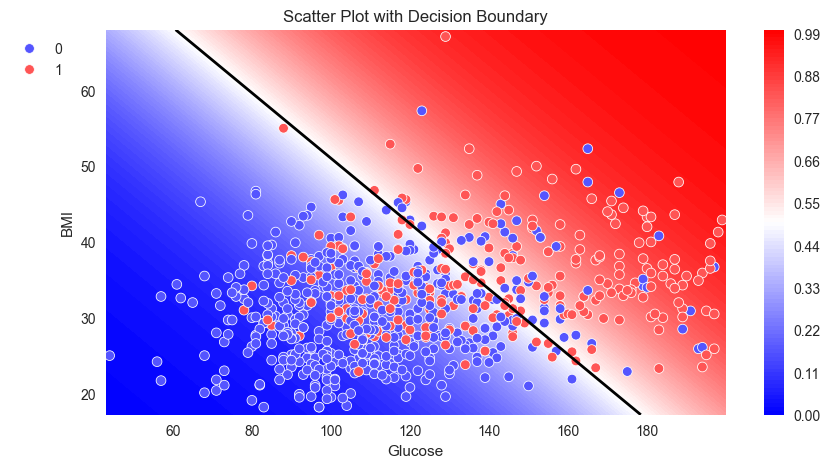

In [17]:
plot_probabilities_2d(X, y, log_reg_2d)

Мы видим разделяющую поверхность (обозначена чёрной линией). Она делит пространство на две части: красное соответствует точкам, которые будут отнесены моделью к классу 1, а синее соответствует точкам, которые будут отнесены моделью к классу 0.

Справа от графика есть цветовая панель, которая показывает значение вероятности того, что пациент болен диабетом (по мнению модели).

>Обратите внимание, что чем более точка удалена от разделяющей плоскости, тем с большей вероятностью модель относит её к тому или иному классу. На тепловой карте это прослеживается в интенсивности синего и красного цвета.

Из графика видно, что довольно много синих точек попали в красную зону и наоборот. Видимо, информации о двух факторах всё же маловато для того, чтобы хорошо провести классификацию.

Давайте будем использовать для построения модели всю предоставленную нам информацию — все факторы из набора данных. Для этого заново создадим матрицу наблюдений X и вектор ответов y:

---

In [18]:
#Создаём матрицу признаков X и столбец с ответами y
X = diabetes_data.drop('Outcome', axis=1)
y = diabetes_data['Outcome']

Затем обучим модель логистической регрессии с помощью метода ```fit()```.

Сделаем предсказание вероятности заболевания диабетом для каждого пациента и самих классов с помощью методов ```predict_proba()``` и ```predict()```.

In [19]:
#Создаём объект класса LogisticRegression
log_reg_full = linear_model.LogisticRegression(random_state=42, max_iter=1000)
#Обучаем модель, минимизируя logloss
log_reg_full.fit(X, y)
#Делаем предсказание класса
y_pred = log_reg_full.predict(X)

Затем добавим предсказание в таблицу X для наглядности:

In [20]:
#Создадим временную таблицу X
X_temp = X.copy()
#Добавим в эту таблицу результат предсказания
X_temp['Prediction'] = y_pred
X_temp.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Prediction
752,5,139.0,64.0,35.0,28.6,0.411,26,0
753,1,96.0,122.0,29.0,22.4,0.207,27,0
754,10,101.0,86.0,37.0,45.6,1.136,38,1
755,0,141.0,72.0,29.0,42.4,0.205,29,1
756,0,125.0,96.0,29.0,22.5,0.262,21,0


Итак, мы сделали предсказание для каждого наблюдения (пациента) из таблицы X.

К сожалению, теперь, когда признаков больше двух, построить красивую визуализацию разделяющей плоскости не получится.

→ Но как же тогда узнать, насколько хорошо модель определяет наличие диабета у пациента? Для этого используются метрики классификации

---

In [28]:
data = pd.read_csv('data_ml3/task_data.csv')
data.head()

,SNo,X_1,X_2,y
0,0,-0.869144,0.389310,0.0
1,1,-0.993467,-0.610591,0.0
2,2,-0.834064,0.239236,0.0
3,3,-0.136471,0.632003,1.0
4,4,0.403887,0.310784,1.0


In [29]:
data.shape

(100, 4)

Таблица состоит из четырёх столбцов:
* SNo — номер строки (данный столбец вам не понадобится, вы можете сразу его удалить);
* X_1 и X_2 — факторы;
* y — целевой признак.

In [41]:
X = data[['X_1', 'X_2']]
y = data['y']

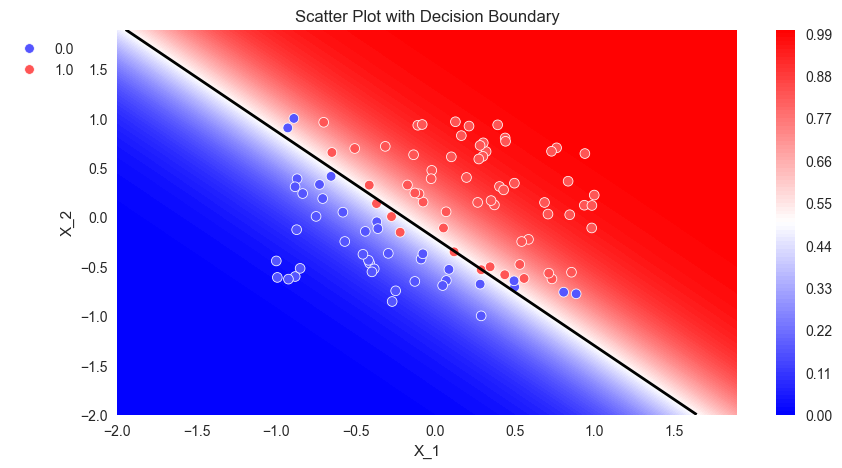

In [42]:
#Создаём объект класса LogisticRegression
log_reg = linear_model.LogisticRegression(random_state=42, solver = 'sag')
#Обучаем модель, минимизируя logloss
log_reg.fit(X, y)
plot_probabilities_2d(X, y, log_reg)